<a href="https://colab.research.google.com/github/irenerendon/Pre_Entrega_Machine_learning/blob/main/Tp1/Talento_Tech_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Entrega — Proyecto de Machine Learning

## Análisis de factores ambientales y químicos que influyen en la velocidad de corrosión en aceros inoxidables

**Estudiante:** Irene Rendón
**Curso:** Machine Learning
**Fecha de entrega:** Mayo 2026

# 1. Selección del Dataset

## Descripción general

El presente trabajo utiliza el dataset **CORR-DATA**, una base de datos orientada al estudio de procesos de corrosión en materiales metálicos bajo diferentes condiciones químicas y ambientales.

El dataset fue desarrollado por la organización estadounidense **NIST (National Institute of Standards and Technology)** y se encuentra disponible públicamente a través del portal oficial de datos del gobierno de Estados Unidos:

[Dataset CORR-DATA](https://catalog.data.gov/dataset/corr-data-f703c)

## Problema abordado

La corrosión en aceros inoxidables representa una problemática relevante en múltiples industrias, debido a su impacto sobre la vida útil de estructuras, componentes y equipos metálicos.

El objetivo del proyecto es analizar cómo diferentes variables ambientales y químicas influyen en la velocidad de corrosión de los materiales, especialmente en aceros inoxidables. Para ello, se trabajará sobre variables relacionadas con temperatura, entorno químico, duración de exposición y concentración de sustancias corrosivas.

Desde el enfoque de machine learning, el trabajo busca preparar y analizar el dataset para futuras etapas de modelado predictivo orientadas a estimar el comportamiento frente a la corrosión bajo distintas condiciones operativas.

## Justificación de la elección del dataset

El dataset fue seleccionado debido a que presenta características adecuadas para desarrollar un flujo de trabajo de análisis de datos y machine learning aplicado a un problema real de ingeniería.

Además, contiene variables numéricas y categóricas, presencia de valores faltantes y múltiples factores relacionados con el fenómeno de corrosión, permitiendo aplicar técnicas de limpieza, transformación, exploración y selección de variables.

La temática también resulta relevante desde el punto de vista industrial, ya que comprender y predecir la corrosión puede contribuir a tareas de mantenimiento preventivo, selección de materiales y optimización de procesos.

## Variables seleccionadas

Para el desarrollo del análisis se utilizarán las siguientes variables del dataset:

* Environment
* Material Group
* Material Family
* Material
* Rate (mm/yr) or Rating
* Localized Attack
* Condition/Comment
* Concentration (Vol %)
* Temperature (deg C)
* Duration

Las variables restantes fueron descartadas debido a que corresponden principalmente a identificadores, referencias bibliográficas o códigos internos del material, aportando bajo valor analítico para los objetivos del proyecto.

#Importo librerias

In [ ]:
#importar librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Cargo dataset

In [ ]:
#cargar dataset

dataset = pd.read_csv('/CORR-DATA_Database.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dimensiones del dataset
df = dataset[['Environment', 'Material Group', 'Material Family', 'Material', 'Rate (mm/yr) or Rating', 'Localized Attack', 'Condition/Comment','Concentration (Vol %)', 'Temperature (deg C)', 'Duration']].reset_index(drop=True)
print(df.shape)

(24721, 10)


#Verifico columnas, para filtrar luegolas necesarias

In [ ]:
(dataset).columns

Index(['Environment', 'Material Group', 'Material Family', 'Material',
       'Rate (mm/yr) or Rating', 'Rate (mils/yr) or Rating',
       'Localized Attack', 'UNS', 'Condition/Comment', 'Concentration (Vol %)',
       'Temperature (deg C)', 'Temperature (deg F)', 'Duration', 'Reference #',
       'Reference'],
      dtype='object')

#Traigo las columnas a trabajar

In [ ]:
#traer columnas necesarias: Enviroment, Material grop, Material Family, Material, Rate (mm/yr), Concentration, Temperature (deg C), Duration

df = dataset[['Environment', 'Material Group', 'Material Family', 'Material', 'Rate (mm/yr) or Rating', 'Localized Attack', 'Condition/Comment','Concentration (Vol %)', 'Temperature (deg C)', 'Duration']].reset_index(drop=True)
df

,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Miscellaneous,Magnesium and alloys,Magnesium,D (Poor),NaN,NaN,All,NaN,NaN
1,Acetaldehyde,Miscellaneous,Noble metals,Platinum,0.05 max,NaN,NaN,Pure,200-400,NaN
2,Acetaldehyde,Miscellaneous,Noble metals,Silver,0.05 max,NaN,NaN,Pure,200-400,NaN
3,Acetaldehyde,Refractory metals and alloys,Titanium and alloys,Titanium,0.001,NaN,NaN,75,149,NaN
4,Acetaldehyde,Refractory metals and alloys,Titanium and alloys,Titanium,A (Resistant),NaN,NaN,100,149,NaN
...,...,...,...,...,...,...,...,...,...,...
24716,Zinc Sulfate,Stainless steels,Ferritic,434,A (Resistant),NaN,NaN,Saturated,Boiling,NaN
24717,Zinc Sulfate,Stainless steels,Martensitic,403,C (Questionable),NaN,NaN,Saturated,Boiling,NaN
24718,Zinc Sulfate,Stainless steels,Martensitic,410,C (Questionable),NaN,NaN,Saturated,Boiling,NaN
24719,Zinc Sulfate,Stainless steels,Martensitic,416,C (Questionable),NaN,NaN,Saturated,Boiling,NaN


#Verificamos los nulo para ver como abordar el dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24721 entries, 0 to 24720
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             24721 non-null  object
 1   Material Group          24721 non-null  object
 2   Material Family         24721 non-null  object
 3   Material                24719 non-null  object
 4   Rate (mm/yr) or Rating  24354 non-null  object
 5   Localized Attack        2784 non-null   object
 6   Condition/Comment       10193 non-null  object
 7   Concentration (Vol %)   15202 non-null  object
 8   Temperature (deg C)     21335 non-null  object
 9   Duration                4546 non-null   object
dtypes: object(10)
memory usage: 1.9+ MB


#Solo traemos los entornos que sean aceros inoxidables y volvemos a verificar la cant de datos

In [ ]:
df_aceros = df[df['Material Group'] == 'Stainless steels'].reset_index(drop=True)
df_aceros

,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic,304,0.003,NaN,Rayon processing; field or pilot plant test; n...,100,61,414 d
1,Acetaldehyde,Stainless steels,Austenitic,316,0.1,Slight pitting,Chemical processing; field or pilot plant test...,70,118,169 d
2,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),NaN,Chemical processing; field or pilot plant test...,70,104,100 d
3,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),NaN,Chemical processing; field or pilot plant test...,50,92,246 d
4,Acetaldehyde,Stainless steels,Austenitic,316,0.003 max,NaN,Chemical processing; field or pilot plant test...,50,92,81 d
...,...,...,...,...,...,...,...,...,...,...
16114,Zinc Sulfate,Stainless steels,Ferritic,434,A (Resistant),NaN,NaN,Saturated,Boiling,NaN
16115,Zinc Sulfate,Stainless steels,Martensitic,403,C (Questionable),NaN,NaN,Saturated,Boiling,NaN
16116,Zinc Sulfate,Stainless steels,Martensitic,410,C (Questionable),NaN,NaN,Saturated,Boiling,NaN
16117,Zinc Sulfate,Stainless steels,Martensitic,416,C (Questionable),NaN,NaN,Saturated,Boiling,NaN


In [ ]:
df_aceros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16119 entries, 0 to 16118
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             16119 non-null  object
 1   Material Group          16119 non-null  object
 2   Material Family         16119 non-null  object
 3   Material                16119 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        2500 non-null   object
 6   Condition/Comment       5131 non-null   object
 7   Concentration (Vol %)   10279 non-null  object
 8   Temperature (deg C)     15518 non-null  object
 9   Duration                1882 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


#Eliminamos los nulos de rate, ya que son los que menos nulos poseen y no modifican en mucho el dataset

In [ ]:
#eliminacion de los nulos de rate ya que son los de menor medida

df_aceros_drop_rate = df_aceros.dropna(subset=['Rate (mm/yr) or Rating']).reset_index(drop=True)

In [ ]:
df_aceros_drop_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15899 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15899 non-null  object
 1   Material Group          15899 non-null  object
 2   Material Family         15899 non-null  object
 3   Material                15899 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        2331 non-null   object
 6   Condition/Comment       4932 non-null   object
 7   Concentration (Vol %)   10189 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1678 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


#Seguimos con la columna Attack, verificamos los valores unicos y rellenamos los datos nulos con esta informacion de forma aleatoria

In [ ]:
# llenar los espacios nulos de Localized Attack con valores aleatorios

df_aceros_attack = df_aceros_drop_rate.copy()
lista = (df_aceros_attack['Localized Attack'].unique()).tolist()
print(lista)

[nan, 'Slight pitting ', 'Intergranular', 'Moderate pitting', 'Pitting', 'Slight pitting', 'Severe pitting', 'Susceptible to pitting and stress-corrosion cracking. ', 'Pitting 70 mils', 'Moderate pitting. Crevice attack', 'Crevice attack', 'Severe pitting; severe attack under spacer', 'Severe  pitting', 'Moderate pitting: stress-corrosion cracking', ' Severe pitting: crevice attack', 'Severe pitting: stress-corrosion cracking', 'Moderate pitting: crevice attack', 'Maximum depth of pits from incipient to 0.005in.', 'Severe pitting; crevice attack.', 'Crevice corrosion', 'Severe pitting Crevice attack', 'Intergranular corrosion', 'Crevice maximum under rubber band .37 (15)', 'Crevice maximum under rubber band .35 (14)', 'Crevice maximum under rubber band .27 (11)', 'Crevice maximum under rubber band .28 (11)', 'Crevice maximum under rubber band .26 (10)', 'Crevice maximum under rubber band .28 (10)', 'Crevice maximum under rubber band .20 (8)', 'Crevice maximum under rubber band .14 (6)'

In [ ]:
#borrar el primer elemnento de la liosta que es nan
lista = lista[1:]
print(lista)

['Slight pitting ', 'Intergranular', 'Moderate pitting', 'Pitting', 'Slight pitting', 'Severe pitting', 'Susceptible to pitting and stress-corrosion cracking. ', 'Pitting 70 mils', 'Moderate pitting. Crevice attack', 'Crevice attack', 'Severe pitting; severe attack under spacer', 'Severe  pitting', 'Moderate pitting: stress-corrosion cracking', ' Severe pitting: crevice attack', 'Severe pitting: stress-corrosion cracking', 'Moderate pitting: crevice attack', 'Maximum depth of pits from incipient to 0.005in.', 'Severe pitting; crevice attack.', 'Crevice corrosion', 'Severe pitting Crevice attack', 'Intergranular corrosion', 'Crevice maximum under rubber band .37 (15)', 'Crevice maximum under rubber band .35 (14)', 'Crevice maximum under rubber band .27 (11)', 'Crevice maximum under rubber band .28 (11)', 'Crevice maximum under rubber band .26 (10)', 'Crevice maximum under rubber band .28 (10)', 'Crevice maximum under rubber band .20 (8)', 'Crevice maximum under rubber band .14 (6)', 'Cr

In [ ]:
df_aceros_attack['Localized Attack'].fillna(np.random.choice(lista), inplace=True)
df_aceros_attack

/tmp/ipykernel_2637/1105215764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_aceros_attack['Localized Attack'].fillna(np.random.choice(lista), inplace=True)


,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic,304,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100,61,414 d
1,Acetaldehyde,Stainless steels,Austenitic,316,0.1,Slight pitting,Chemical processing; field or pilot plant test...,70,118,169 d
2,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70,104,100 d
3,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,246 d
4,Acetaldehyde,Stainless steels,Austenitic,316,0.003 max,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,81 d
...,...,...,...,...,...,...,...,...,...,...
15894,Zinc Sulfate,Stainless steels,Ferritic,434,A (Resistant),Severe pitting; crevice attack.,NaN,Saturated,Boiling,NaN
15895,Zinc Sulfate,Stainless steels,Martensitic,403,C (Questionable),Severe pitting; crevice attack.,NaN,Saturated,Boiling,NaN
15896,Zinc Sulfate,Stainless steels,Martensitic,410,C (Questionable),Severe pitting; crevice attack.,NaN,Saturated,Boiling,NaN
15897,Zinc Sulfate,Stainless steels,Martensitic,416,C (Questionable),Severe pitting; crevice attack.,NaN,Saturated,Boiling,NaN


In [ ]:
df_aceros_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15899 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15899 non-null  object
 1   Material Group          15899 non-null  object
 2   Material Family         15899 non-null  object
 3   Material                15899 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        15899 non-null  object
 6   Condition/Comment       4932 non-null   object
 7   Concentration (Vol %)   10189 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1678 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


#Seguimos con la columna Condition, llenamos los valores nulos como No Especificados

In [ ]:
df_aceros_condition = df_aceros_attack.copy()

In [ ]:
#LLenamos los nulos de los comentarios o condiciones como no especificados

df_aceros_condition['Condition/Comment'].fillna('No Especificado', inplace=True)
df_aceros_condition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15899 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15899 non-null  object
 1   Material Group          15899 non-null  object
 2   Material Family         15899 non-null  object
 3   Material                15899 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        15899 non-null  object
 6   Condition/Comment       15899 non-null  object
 7   Concentration (Vol %)   10189 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1678 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


/tmp/ipykernel_2637/1747579711.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_aceros_condition['Condition/Comment'].fillna('No Especificado', inplace=True)


#Seguimos con la columna Concentration, llenamos los valores nulos como No Especificados

In [ ]:
df_aceros_concentration = df_aceros_condition.copy()
df_aceros_concentration['Concentration (Vol %)'].fillna('No Especificado', inplace=True)
df_aceros_concentration

/tmp/ipykernel_2637/2727908294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_aceros_concentration['Concentration (Vol %)'].fillna('No Especificado', inplace=True)


,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic,304,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100,61,414 d
1,Acetaldehyde,Stainless steels,Austenitic,316,0.1,Slight pitting,Chemical processing; field or pilot plant test...,70,118,169 d
2,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70,104,100 d
3,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,246 d
4,Acetaldehyde,Stainless steels,Austenitic,316,0.003 max,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,81 d
...,...,...,...,...,...,...,...,...,...,...
15894,Zinc Sulfate,Stainless steels,Ferritic,434,A (Resistant),Severe pitting; crevice attack.,No Especificado,Saturated,Boiling,NaN
15895,Zinc Sulfate,Stainless steels,Martensitic,403,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,Boiling,NaN
15896,Zinc Sulfate,Stainless steels,Martensitic,410,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,Boiling,NaN
15897,Zinc Sulfate,Stainless steels,Martensitic,416,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,Boiling,NaN


In [ ]:
df_aceros_concentration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15899 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15899 non-null  object
 1   Material Group          15899 non-null  object
 2   Material Family         15899 non-null  object
 3   Material                15899 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        15899 non-null  object
 6   Condition/Comment       15899 non-null  object
 7   Concentration (Vol %)   15899 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1678 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


#Ahora verificamos Temperature, se cambiara los valores Boiling por los puntos de ebullicion de cada uno, y Room con los valores de temperatura ambiente.

In [ ]:
df_aceros_temperature = df_aceros_concentration.copy()

In [ ]:
#Creo una lista con los elementos que poseen el valor Boiling para buscar en internet sus puntos de ebullicion
entornos_ebullicion = df_aceros_temperature.loc[df_aceros_temperature['Temperature (deg C)'] == 'Boiling']['Environment'].unique()
print(entornos_ebullicion)

['Acetic Acid' 'Acetic Anhydride' 'Acetochloride' 'Acetone'
 'Aluminum Acetate' 'Aluminum Ammonium Sulfate' 'Aluminum Sulfate'
 'Ammonium Carbonate' 'Ammonium Chloride' 'Ammonium Hydroxide'
 'Ammonium Nitrate' 'Ammonium Oxalate' 'Ammonium Perchlorate'
 'Ammonium Sulfate' 'Ammonium Sulfite' 'Barium Chloride Dihydrate'
 'Barium Hydroxide' 'Barium Nitrate' 'Benzoic Acid' 'Benzole' 'Boric Acid'
 'Bromine' 'Butyric Acid' 'Calcium Bisulfite' 'Calcium Chloride'
 'Calcium Hydroxide' 'Carbon Tetrachloride' 'Carnallite' 'Chlorobenzene'
 'Chloroform' 'Chromic Acid' 'Citric Acid' 'Creosote' 'Cupric Sulfate'
 'Cuprous Acetate' 'Cuprous Cyanide' 'Cuprous Nitrate' 'Cuprous Sulfate'
 'Dichloroethylene' 'Diethyl Ether' 'Disulfur Dichloride' 'Ethyl Alcohol'
 'Fatty Acid' 'Ferrous Sulfate' 'Food Products' 'Formaldehyde'
 'Formic Acid' 'Fruit Juices' 'Gallic Acid' 'Glue (also acid)' 'Glycerine'
 'Hydrazine Sulfate' 'Hydrochloric Acid' 'Hydroxylamine Sulfate'
 'Lactic Acid' 'Lead Acetate' 'Lubricating Oil'

In [ ]:
lista_elementos = list(entornos_ebullicion)
print(lista_elementos)

['Acetic Acid', 'Acetic Anhydride', 'Acetochloride', 'Acetone', 'Aluminum Acetate', 'Aluminum Ammonium Sulfate', 'Aluminum Sulfate', 'Ammonium Carbonate', 'Ammonium Chloride', 'Ammonium Hydroxide', 'Ammonium Nitrate', 'Ammonium Oxalate', 'Ammonium Perchlorate', 'Ammonium Sulfate', 'Ammonium Sulfite', 'Barium Chloride Dihydrate', 'Barium Hydroxide', 'Barium Nitrate', 'Benzoic Acid', 'Benzole', 'Boric Acid', 'Bromine', 'Butyric Acid', 'Calcium Bisulfite', 'Calcium Chloride', 'Calcium Hydroxide', 'Carbon Tetrachloride', 'Carnallite', 'Chlorobenzene', 'Chloroform', 'Chromic Acid', 'Citric Acid', 'Creosote', 'Cupric Sulfate', 'Cuprous Acetate', 'Cuprous Cyanide', 'Cuprous Nitrate', 'Cuprous Sulfate', 'Dichloroethylene', 'Diethyl Ether', 'Disulfur Dichloride', 'Ethyl Alcohol', 'Fatty Acid', 'Ferrous Sulfate', 'Food Products', 'Formaldehyde', 'Formic Acid', 'Fruit Juices', 'Gallic Acid', 'Glue (also acid)', 'Glycerine', 'Hydrazine Sulfate', 'Hydrochloric Acid', 'Hydroxylamine Sulfate', 'Lacti

In [ ]:
#Mapeo los entornos con sus puntos de ebullicion correspondiente

boiling_points_c = [
    "118.1", "139.8", "52", "56.1", "200", "280", "770", "58", "338", "38",
    "210", "70", "240", "235", "65", "1560", "780", "590", "249.2", "80.1",
    "300", "58.8", "163.5", "100", "1935", "580", "76.7", "1412", "131.7", "61.2",
    "250", "175", "200", "650", "250", "473", "170", "650", "48", "34.6",
    "137.1", "78.3", "360", "300", "N/A", "-19.1", "100.8", "100", "210", "100",
    "290", "254", "108.6", "170", "122", "280", "300", "1124", "1190", "178",
    "302", "70", "-24.2", "39.6", "840", "83", "157", "175", "200", "181.7",
    "158", "200", "200", "891", "400", "1420", "100", "500", "300", "400",
    "1327", "1330", "400", "350", "240", "1689", "58", "100.7", "440", "324",
    "315", "150", "1600", "300", "1413", "180", "250", "1388", "101", "380",
    "320", "480", "657", "100", "1100", "1429", "1180", "600", "1575", "100",
    "114.1", "623", "337", "210", "170", "123", "110.6", "87.2", "300", "138.5",
    "732", "740"]

mapeo_puntos = dict(zip(lista_elementos, boiling_points_c))

In [ ]:
#Traigo todos los entornos que tienen Boiling y cambio esos valores por el mapeo anterior
es_boiling = df_aceros_temperature['Temperature (deg C)'] == 'Boiling'

df_aceros_temperature.loc[es_boiling, 'Temperature (deg C)'] = df_aceros_temperature.loc[es_boiling, 'Environment'].map(mapeo_puntos)

In [ ]:
df_aceros_temperature

,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic,304,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100,61,414 d
1,Acetaldehyde,Stainless steels,Austenitic,316,0.1,Slight pitting,Chemical processing; field or pilot plant test...,70,118,169 d
2,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70,104,100 d
3,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,246 d
4,Acetaldehyde,Stainless steels,Austenitic,316,0.003 max,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92,81 d
...,...,...,...,...,...,...,...,...,...,...
15894,Zinc Sulfate,Stainless steels,Ferritic,434,A (Resistant),Severe pitting; crevice attack.,No Especificado,Saturated,740,NaN
15895,Zinc Sulfate,Stainless steels,Martensitic,403,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,740,NaN
15896,Zinc Sulfate,Stainless steels,Martensitic,410,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,740,NaN
15897,Zinc Sulfate,Stainless steels,Martensitic,416,C (Questionable),Severe pitting; crevice attack.,No Especificado,Saturated,740,NaN


In [ ]:
#Hago lo mismo pero para los valores Room, el cual se considera a 25 grados centigrados

es_room = df_aceros_temperature['Temperature (deg C)'] == 'Room'

df_aceros_temperature.loc[es_room, 'Temperature (deg C)'] = '25'

In [ ]:
df_aceros_temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15899 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15899 non-null  object
 1   Material Group          15899 non-null  object
 2   Material Family         15899 non-null  object
 3   Material                15899 non-null  object
 4   Rate (mm/yr) or Rating  15899 non-null  object
 5   Localized Attack        15899 non-null  object
 6   Condition/Comment       15899 non-null  object
 7   Concentration (Vol %)   15899 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1678 non-null   object
dtypes: object(10)
memory usage: 1.2+ MB


In [ ]:
#Como la diferencia de temperatura respecto a los nulos disminuyo, terminados descartando todos esos valores nulos.

df_aceros_temperature.dropna(subset=['Temperature (deg C)'], inplace=True)
df_aceros_temperature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15381 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Environment             15381 non-null  object
 1   Material Group          15381 non-null  object
 2   Material Family         15381 non-null  object
 3   Material                15381 non-null  object
 4   Rate (mm/yr) or Rating  15381 non-null  object
 5   Localized Attack        15381 non-null  object
 6   Condition/Comment       15381 non-null  object
 7   Concentration (Vol %)   15381 non-null  object
 8   Temperature (deg C)     15381 non-null  object
 9   Duration                1644 non-null   object
dtypes: object(10)
memory usage: 1.3+ MB


In [ ]:
#Algunos valores estan en tipo string aun debido a que la informacion se encuentra entre ambos valores, se calcula el prodio de esos mediante la siguiente funncion

def procesar_rangos(valor):
    # Verificamos si el valor es un string y tiene un guion
    if isinstance(valor, str) and '-' in valor:
        try:
            # Dividimos por el guion y convertimos a float
            partes = valor.split('-')
            # Calculamos el promedio de los dos extremos
            return (float(partes[0]) + float(partes[1])) / 2
        except:
            # Si algo falla (ej. hay un espacio raro), devolvemos el valor original
            return valor
    return valor

#Aplicamos la función a la columna
df_aceros_temperature['Temperature (deg C)'] = df_aceros_temperature['Temperature (deg C)'].apply(procesar_rangos)

In [ ]:
df_aceros_temperature['Temperature (deg C)'].unique()

array(['61', '118', '104', '92', 100.5, '66', '25', '106', '110', '116',
       '122', '128', '130', '20', '118.1', '50', '90', '15', '21', 101.5,
       '150', '139.8', 136.0, 133.0, 133.5, '137', '131', '134', '52',
       '56.1', '57', '80', '63', '58', '200', '280', 68.0, '26', '770',
       110.0, '79', '88', '29', '82', 104.0, 79.0, '65', '102', '105',
       37.5, '100', '338', '49', 55.0, '60', '204', '121', 113.0, '51',
       '16', '93', '38', '70', '177', '210', '143', '53', '240', '28',
       60.0, 110.5, '235', 79.5, 42.5, 65.5, '845', '35', '1560', '780',
       '590', 98.5, '185', '77', '249.2', '138', '80.1', '300', '91',
       '24', '58.8', '171', 62.0, '175', '129', '163.5', '1935', '-12',
       '-15 to -16', 69.5, '71', '165', '-15to-16', '580',
       'Up to 40° (104°)', 22.0, 35.0, '36', '190', 343.0, '215', '43',
       'Room to 110 (230)', 'Room to 100 (230)', 'Hot', 114.5, 175.0,
       '76.7', 53.0, 72.5, '142', '1412', '315', '340', '400', '450',
       '29

In [ ]:
#Ahora los pasamos al tipo de dato numerico

# 2. Ahora que no hay rangos (99-102 -> 100.5), convertimos todo a float
# errors='coerce' transformará los "N/A" o textos no numéricos en NaN (vacíos)
df_aceros_temperature['Temperature (deg C)'] = pd.to_numeric(df_aceros_temperature['Temperature (deg C)'], errors='coerce')
df_aceros_temperature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15381 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             15381 non-null  object 
 1   Material Group          15381 non-null  object 
 2   Material Family         15381 non-null  object 
 3   Material                15381 non-null  object 
 4   Rate (mm/yr) or Rating  15381 non-null  object 
 5   Localized Attack        15381 non-null  object 
 6   Condition/Comment       15381 non-null  object 
 7   Concentration (Vol %)   15381 non-null  object 
 8   Temperature (deg C)     14912 non-null  float64
 9   Duration                1644 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.3+ MB


In [ ]:
#volvemos a elinar los nulos de temperature

df_aceros_temperature.dropna(subset=['Temperature (deg C)'], inplace=True)
df_aceros_temperature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14912 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             14912 non-null  object 
 1   Material Group          14912 non-null  object 
 2   Material Family         14912 non-null  object 
 3   Material                14912 non-null  object 
 4   Rate (mm/yr) or Rating  14912 non-null  object 
 5   Localized Attack        14912 non-null  object 
 6   Condition/Comment       14912 non-null  object 
 7   Concentration (Vol %)   14912 non-null  object 
 8   Temperature (deg C)     14912 non-null  float64
 9   Duration                1612 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.3+ MB


#Ahora verificamos Duration, considerando que los entronos dan informacion de mm/años, vamos a llenar los nulos o espacios vacios con valores minimos a 365 dias de observacion

In [ ]:
#llenar el tiempo de duration

df_aceros_duration = df_aceros_temperature.copy()
df_aceros_duration['Duration'] = df_aceros_duration['Duration'].fillna('365')


In [ ]:
df_aceros_duration.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14912 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             14912 non-null  object 
 1   Material Group          14912 non-null  object 
 2   Material Family         14912 non-null  object 
 3   Material                14912 non-null  object 
 4   Rate (mm/yr) or Rating  14912 non-null  object 
 5   Localized Attack        14912 non-null  object 
 6   Condition/Comment       14912 non-null  object 
 7   Concentration (Vol %)   14912 non-null  object 
 8   Temperature (deg C)     14912 non-null  float64
 9   Duration                14912 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.3+ MB


In [ ]:
#cambiar el tipo de datos de duration
df_aceros_duration['Duration'] = df_aceros_duration['Duration'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df_aceros_duration['Duration'] = df_aceros_duration['Duration'].astype(float)

In [ ]:
df_aceros_duration.head(50)

,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic,304,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100,61.0,414.0
1,Acetaldehyde,Stainless steels,Austenitic,316,0.1,Slight pitting,Chemical processing; field or pilot plant test...,70,118.0,169.0
2,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70,104.0,100.0
3,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92.0,246.0
4,Acetaldehyde,Stainless steels,Austenitic,316,0.003 max,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92.0,81.0
5,Acetaldehyde,Stainless steels,Austenitic,316,0.003,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70,100.5,84.5
6,Acetaldehyde,Stainless steels,Austenitic,316,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100,61.0,414.0
7,Acetaldehyde,Stainless steels,Austenitic,316,A (Resistant),Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,97-98,66.0,294.0
8,Acetaldehyde,Stainless steels,Austenitic,317,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92.0,81.0
9,Acetaldehyde,Stainless steels,Austenitic,317,A (Resistant),Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50,92.0,246.0


#Vuelvo a tomar la columna concentration, para modificar los valores promedios con la funcion y luego convertir los string en NaN para evaluar si llenar con la media o mediana

In [ ]:
df_aceros_concentration2 = df_aceros_duration.copy()

In [ ]:
# 1. Aplicamos la función a la columna
df_aceros_concentration2['Concentration (Vol %)'] = df_aceros_concentration2['Concentration (Vol %)'].apply(procesar_rangos)

df_aceros_concentration2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14912 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             14912 non-null  object 
 1   Material Group          14912 non-null  object 
 2   Material Family         14912 non-null  object 
 3   Material                14912 non-null  object 
 4   Rate (mm/yr) or Rating  14912 non-null  object 
 5   Localized Attack        14912 non-null  object 
 6   Condition/Comment       14912 non-null  object 
 7   Concentration (Vol %)   14912 non-null  object 
 8   Temperature (deg C)     14912 non-null  float64
 9   Duration                14912 non-null  float64
dtypes: float64(2), object(8)
memory usage: 1.3+ MB


In [ ]:
#cambiar el tipo de datos de duration
df_aceros_concentration2['Concentration (Vol %)'] = df_aceros_concentration2['Concentration (Vol %)'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

In [ ]:
df_aceros_concentration2['Concentration (Vol %)'] = pd.to_numeric(df_aceros_concentration2['Concentration (Vol %)'], errors='coerce')

In [ ]:
df_aceros_concentration2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14912 entries, 0 to 15898
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             14912 non-null  object 
 1   Material Group          14912 non-null  object 
 2   Material Family         14912 non-null  object 
 3   Material                14912 non-null  object 
 4   Rate (mm/yr) or Rating  14912 non-null  object 
 5   Localized Attack        14912 non-null  object 
 6   Condition/Comment       14912 non-null  object 
 7   Concentration (Vol %)   7348 non-null   float64
 8   Temperature (deg C)     14912 non-null  float64
 9   Duration                14912 non-null  float64
dtypes: float64(3), object(7)
memory usage: 1.3+ MB


In [ ]:
df_aceros_concentration2.dropna(subset=['Concentration (Vol %)'], inplace=True)
df_aceros_concentration2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7348 entries, 0 to 15636
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             7348 non-null   object 
 1   Material Group          7348 non-null   object 
 2   Material Family         7348 non-null   object 
 3   Material                7348 non-null   object 
 4   Rate (mm/yr) or Rating  7348 non-null   object 
 5   Localized Attack        7348 non-null   object 
 6   Condition/Comment       7348 non-null   object 
 7   Concentration (Vol %)   7348 non-null   float64
 8   Temperature (deg C)     7348 non-null   float64
 9   Duration                7348 non-null   float64
dtypes: float64(3), object(7)
memory usage: 631.5+ KB


#Cambiamos los valores string de Rate por numericos, con aquellos que tienen una calificacion (A,B,C,D)

In [ ]:
df_aceros_rate2 = df_aceros_concentration2.copy()

In [ ]:
# cambiar el tipo de datos de rate, segun caracteristicas indicadas en el manual de descripcion
#A (Resistente) < 0,002; B (Bueno) < 0,020;
#C (Cuestionable) 0,020 - 0,050; D (Malo) > 0,050.

len(df_aceros_rate2['Rate (mm/yr) or Rating'].unique())

401

In [ ]:
df_aceros_rate2['Rate (mm/yr) or Rating'].unique()

array(['0.003', '0.1', 'A (Resistant)', '0.003 max ', '0.018', '0.102',
       '0.127', '0.203', '0.05', '0.013', 'B (Good)', 'C (Questionable)',
       '0.76', '1.68', '1.07', '0.18', '0.75', 'D (Poor)', '0.275',
       '0.0025', '0.0076', '0.069', '0.023', '0.406', '0.56', '0.0075',
       '0.04', '.08-0.5 ', '0.08', '0.025', '0.01', '0.03 max ',
       '.05-0.3 ', '0.005', '0.19', '4.9', '24.2', '8.2', '0.004',
       '0.01 max ', '0.015-0.018 ', '0.37', '0.051 max ', '0.001', '0.28',
       '0.002', '0.16', '0.09', '0', '0.13', '0.3', '0.23', '0.02',
       '0.015', '0.15', '0.075', '0.008', '0.006', '15', '1.5', '5',
       '0.0005', '2.3', '360', '2', '0.083', '0.033', '0.025 max ',
       '0.24', '4.1', '4.4', '3.8', '1', '3.5', '0.048', '0.73', '0.33',
       '8.5', '19', '6', '0.6', '0.003 max', '6.3', '1.3', '4', '0.03',
       '1.7', '0.53', '0.35', '1.4', '0.38', '8.8 max', '1.13', '0.63',
       '0.009', '0.65', '0.035', '0.043', '0.25', '0.55', '0.58', '0.88',
       '39'

In [ ]:
#Funcion para reemplazar los valores especificos, y eliminar caracteres con palabras especificas

import re

def clean_rate(value):
    if pd.isna(value):
        return np.nan

    val_str = str(value).strip()

    # 1. Handle categorical ratings first
    if 'A (Resistant)' in val_str or 'A' == val_str.strip():
        return 0.001
    if 'B (Good)' in val_str or 'B' == val_str.strip():
        return 0.01
    if 'C (Questionable)' in val_str or 'C' == val_str.strip():
        return 0.035
    if 'D (Poor)' in val_str or 'D' == val_str.strip():
        return 0.1

    # 2. Handle numeric ranges (e.g., '.08-0.5')
    if '-' in val_str:
        parts = re.findall(r'[0-9.]+', val_str)
        if len(parts) >= 2:
            return (float(parts[0]) + float(parts[1])) / 2

    # 3. Extract the first valid number (ignoring max, min, min., max., etc.)
    # This regex looks for digits and decimals, ignoring surrounding text
    match = re.search(r'[0-9.]+', val_str.replace(',', ''))
    if match:
        try:
            return float(match.group())
        except:
            return np.nan

    return np.nan

In [ ]:
# Apply the cleaning function
df_aceros_rate2['Rate (mm/yr) or Rating'] = df_aceros_rate2['Rate (mm/yr) or Rating'].apply(clean_rate)

# Show results
display(df_aceros_rate2[['Rate (mm/yr) or Rating']].head(20))
print(f"Column type: {df_aceros_rate2['Rate (mm/yr) or Rating'].dtype}")

,Rate (mm/yr) or Rating
0,0.003
1,0.100
2,0.001
3,0.001
4,0.003
5,0.003
6,0.003
7,0.001
8,0.001
9,0.001


Column type: float64


In [ ]:
df_aceros_rate2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7348 entries, 0 to 15636
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             7348 non-null   object 
 1   Material Group          7348 non-null   object 
 2   Material Family         7348 non-null   object 
 3   Material                7348 non-null   object 
 4   Rate (mm/yr) or Rating  7348 non-null   float64
 5   Localized Attack        7348 non-null   object 
 6   Condition/Comment       7348 non-null   object 
 7   Concentration (Vol %)   7348 non-null   float64
 8   Temperature (deg C)     7348 non-null   float64
 9   Duration                7348 non-null   float64
dtypes: float64(4), object(6)
memory usage: 631.5+ KB


#varificamos los valores unicos de entorno y material group y material family, para corroborar que estamos trabajando solo con materiales relacionados a aceros inoxidables

Link para verificar la decision

https://www.thyssenkrupp-materials.es/es/home/blog/acero-inoxidable/que-es-acero-inoxidable-usos/tipos-acero-inoxidable

In [ ]:
df_aceros2 = df_aceros_rate2.copy()

In [ ]:
#valores unicos de Enviroments

df_aceros2['Environment'].unique()

array(['Acetaldehyde', 'Acetic Acid', 'Acetic Anhydride',
       'Aluminum Chloride', 'Acetone', 'Aluminum Fluoride',
       'Aluminum Sulfate', 'Ammonia', 'Ammonium Carbonate',
       'Ammonium Chloride', 'Sodium Hydroxide', 'Ammonium Fluoride',
       'Ammonium Nitrate', 'Ammonium Perchlorate', 'Ammonium Phosphate',
       'Ammonium Sulfate', 'Aniline Hydrochloride', 'Barium Chloride',
       'Benzene', 'Benzoic Acid', 'Boric Acid', 'Bromine', 'Butane',
       'Butyric Acid', 'Butyl Alcohol', 'Cadmium Sulfate',
       'Calcium Bromide', 'Calcium Chloride', 'Calcium Hypochlorite',
       'Carbon Dioxide', 'Carbon Tetrachloride', 'Chlorine',
       'Chlorine Dioxide', 'Chloroacetic Acid', 'Chlorosulfonic Acid',
       'Chromic Acid', 'Citric Acid', 'Cupric Chloride', 'Cupric Nitrate',
       'Cupric Sulfate', 'Cuprous Nitrate', 'Ethyl Alcohol', 'Fatty Acid',
       'Ferric Chloride', 'Ferric Sulfate', 'Ferrous Chloride',
       'Ferrous Sulfate', 'Fluosilicic Acid', 'Formaldehyde',
   

In [ ]:
#Valores unicos de la cantidad de Material Group

df_aceros2['Material Group'].unique()

array(['Stainless steels'], dtype=object)

In [ ]:
#contar la cantidad de Material Family

df_aceros2['Material Family'].unique()

array(['Austenitic', 'Duplex', 'Ferritic', 'Martensitic', 'Austenitic ',
       'Stainless steel', 'Austenitc', 'Precipitation hardening'],
      dtype=object)

In [ ]:
#borrar satinless steel ya que es redundandte, dentro de los aceros inoxidables solo exiten 5 tipos:
#austenitico, ferritico, martensitico, por precipitacion y duplex

df_aceros2 = df_aceros2[df_aceros2['Material Family'] != 'Stainless steel']
df_aceros2['Material Family'].unique()

array(['Austenitic', 'Duplex', 'Ferritic', 'Martensitic', 'Austenitic ',
       'Austenitc', 'Precipitation hardening'], dtype=object)

In [ ]:
#Modificar los nombres para que coincidan de forma correcta, por ejemplo austenitic

df_aceros2['Material Family'] = df_aceros2['Material Family'].replace({'Austenitic': 'Austenitic steel',
                                            'Austenitic ': 'Austenitic steel',
                                            'Austenitc': 'Austenitic steel',
                                            'Prepcipitation hardening' : 'Precipitation hardening'})
df_aceros2['Material Family'].unique()

array(['Austenitic steel', 'Duplex', 'Ferritic', 'Martensitic',
       'Precipitation hardening'], dtype=object)

#Hago un ultimo conteo de nulos, los tipos de datos y luego copio el dataset para empezar con el analisis

In [ ]:
#Cuneto la cantidad de Nulos

print(df_aceros2.isnull().sum())

Environment               0
Material Group            0
Material Family           0
Material                  0
Rate (mm/yr) or Rating    0
Localized Attack          0
Condition/Comment         0
Concentration (Vol %)     0
Temperature (deg C)       0
Duration                  0
dtype: int64


In [ ]:
df_aceros2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7346 entries, 0 to 15636
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Environment             7346 non-null   object 
 1   Material Group          7346 non-null   object 
 2   Material Family         7346 non-null   object 
 3   Material                7346 non-null   object 
 4   Rate (mm/yr) or Rating  7346 non-null   float64
 5   Localized Attack        7346 non-null   object 
 6   Condition/Comment       7346 non-null   object 
 7   Concentration (Vol %)   7346 non-null   float64
 8   Temperature (deg C)     7346 non-null   float64
 9   Duration                7346 non-null   float64
dtypes: float64(4), object(6)
memory usage: 631.3+ KB


In [ ]:
df_aceros2.head(50)

,Environment,Material Group,Material Family,Material,Rate (mm/yr) or Rating,Localized Attack,Condition/Comment,Concentration (Vol %),Temperature (deg C),Duration
0,Acetaldehyde,Stainless steels,Austenitic steel,304,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100.0,61.0,414.0
1,Acetaldehyde,Stainless steels,Austenitic steel,316,0.100,Slight pitting,Chemical processing; field or pilot plant test...,70.0,118.0,169.0
2,Acetaldehyde,Stainless steels,Austenitic steel,316,0.001,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70.0,104.0,100.0
3,Acetaldehyde,Stainless steels,Austenitic steel,316,0.001,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50.0,92.0,246.0
4,Acetaldehyde,Stainless steels,Austenitic steel,316,0.003,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50.0,92.0,81.0
5,Acetaldehyde,Stainless steels,Austenitic steel,316,0.003,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,70.0,100.5,84.5
6,Acetaldehyde,Stainless steels,Austenitic steel,316,0.003,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,100.0,61.0,414.0
7,Acetaldehyde,Stainless steels,Austenitic steel,316,0.001,Severe pitting; crevice attack.,Rayon processing; field or pilot plant test; n...,97.5,66.0,294.0
8,Acetaldehyde,Stainless steels,Austenitic steel,317,0.001,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50.0,92.0,81.0
9,Acetaldehyde,Stainless steels,Austenitic steel,317,0.001,Severe pitting; crevice attack.,Chemical processing; field or pilot plant test...,50.0,92.0,246.0


In [ ]:
df_aceros_final = df_aceros2.copy()
df_aceros_final.reset_index(drop=True, inplace=True)

#Algunos analisis graficos

## Conteo de familia de Aceros Inoxidables

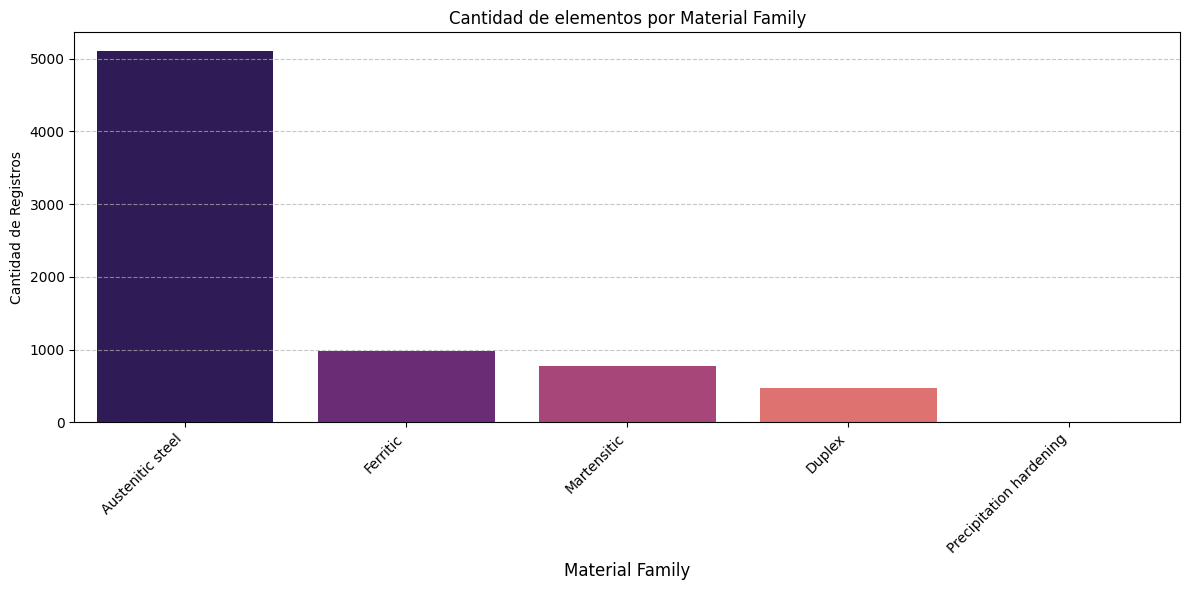

In [ ]:
plt.figure(figsize=(12, 6))
Family_counts = df_aceros_final['Material Family'].value_counts()
# Fixed FutureWarning by assigning hue and setting legend=False
sns.barplot(x=Family_counts.index, y=Family_counts.values, hue=Family_counts.index, palette='magma', legend=False)

plt.title('Cantidad de elementos por Material Family', fontsize=12)
plt.xlabel('Material Family', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conteo de los Material Family en torta

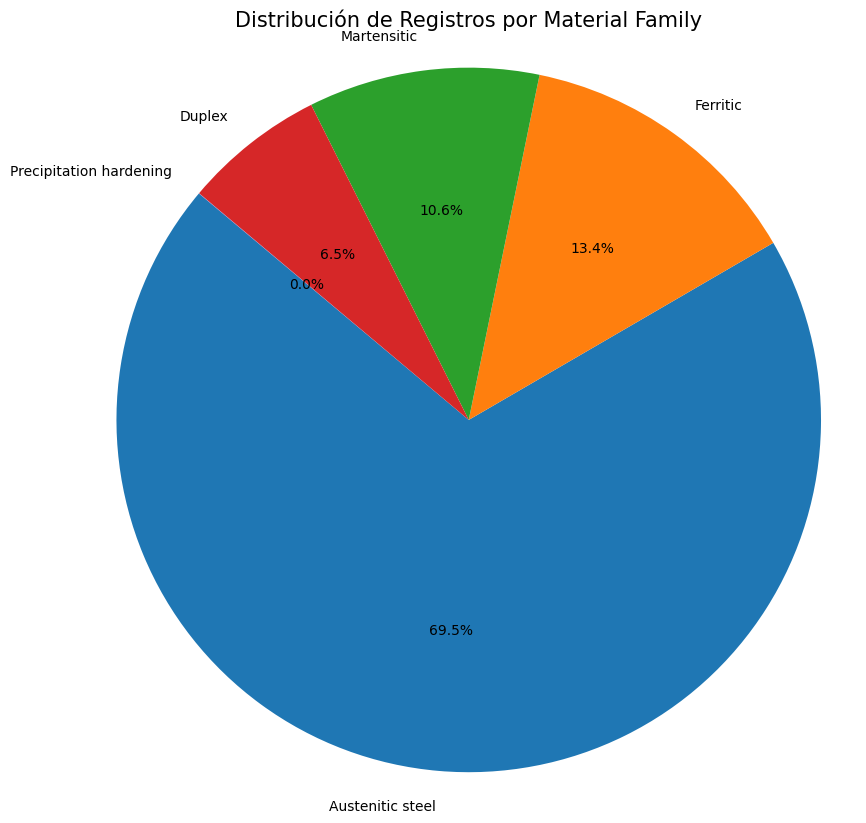

In [ ]:
# Count the occurrences of each Material Family in the original dataset
group_counts = df_aceros_final['Material Family'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', startangle=140)

plt.title('Distribución de Registros por Material Family', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Conteo de los Materiales en barra

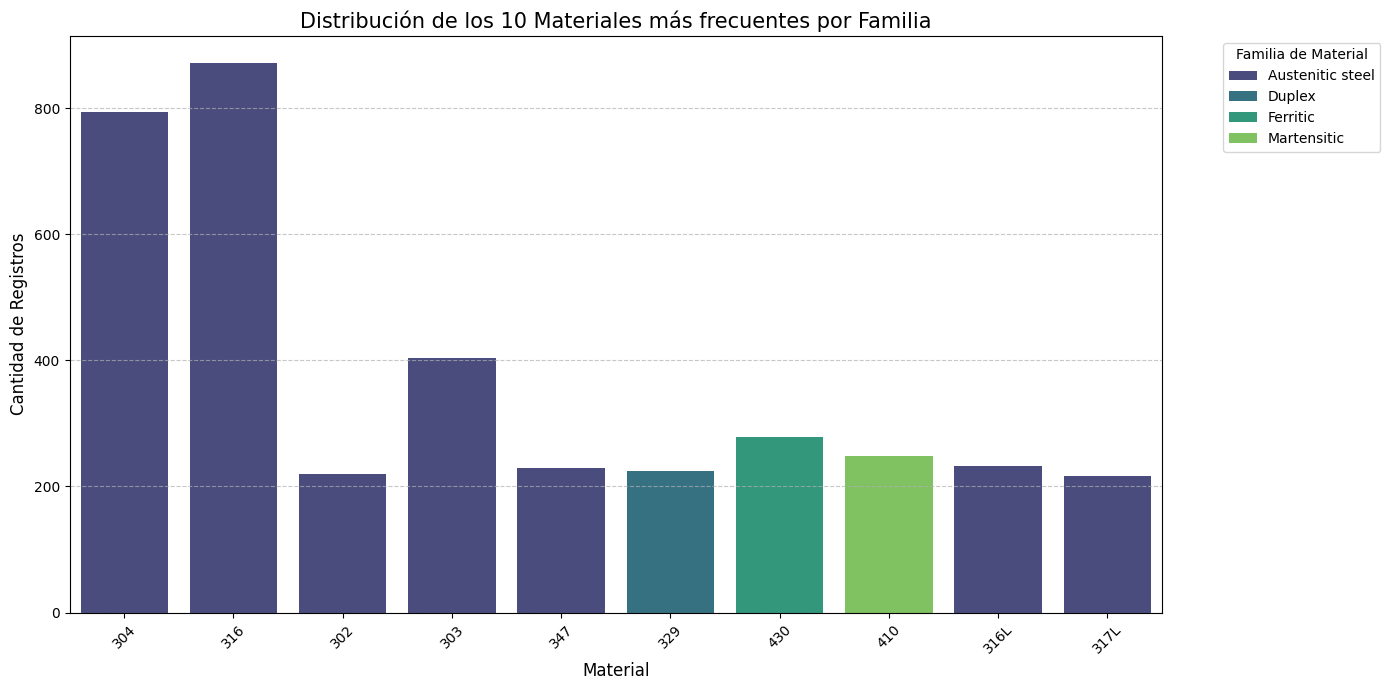

In [ ]:
# Seleccionamos los 10 materiales más frecuentes para que el gráfico sea legible
top_materials = df_aceros_final['Material'].value_counts().nlargest(10).index
df_plot = df_aceros_final[df_aceros_final['Material'].isin(top_materials)]

plt.figure(figsize=(14, 7))
sns.countplot(data=df_plot, x='Material', hue='Material Family', palette='viridis')

plt.title('Distribución de los 10 Materiales más frecuentes por Familia', fontsize=15)
plt.xlabel('Material', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.legend(title='Familia de Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Entornos mas corrosivos (top ten)

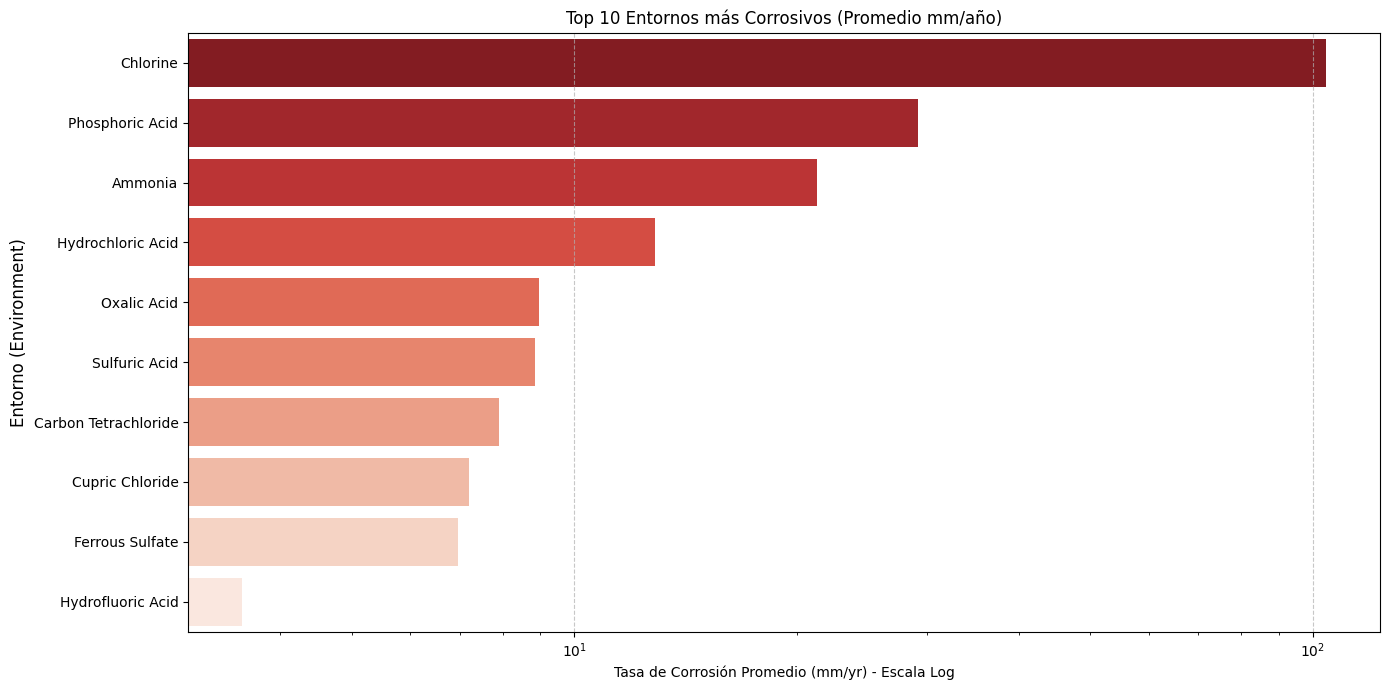

In [ ]:
# Calcular el promedio de tasa de corrosión por entorno
env_corrosion = df_aceros_final.groupby('Environment')['Rate (mm/yr) or Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=env_corrosion.values, y=env_corrosion.index, hue=env_corrosion.index, palette='Reds_r', legend=False)

plt.xscale('log')

plt.title('Top 10 Entornos más Corrosivos (Promedio mm/año)', fontsize=12)
plt.xlabel('Tasa de Corrosión Promedio (mm/yr) - Escala Log', fontsize=10)
plt.ylabel('Entorno (Environment)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Los 5 entornos mas corrosivos con mas datos junto a los 5 materiales mas estudiaos

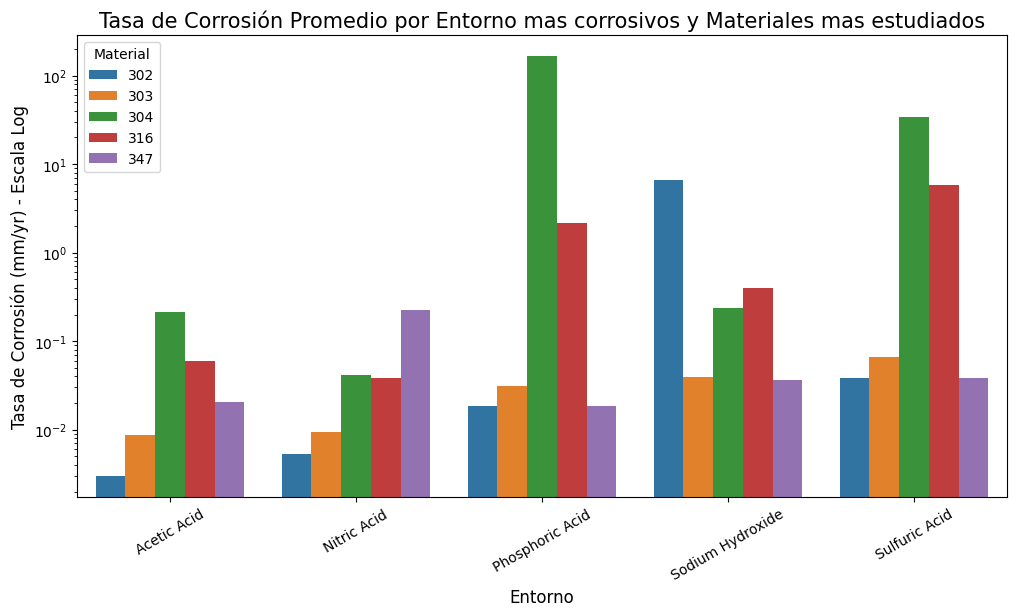

In [ ]:
top_envs = df_aceros_final['Environment'].value_counts().nlargest(5).index
#top_mats = df_aceros_final['Material'].value_counts().nlargest(5).index

most_studied_materials = ['304', '316', '302', '303', '347']
df_entornos_materiales = df_aceros_final[df_aceros_final['Environment'].isin(top_envs) & (df_aceros_final['Material'].isin(most_studied_materials))]

#df_env_plot = df_aceros_final[df_aceros_final['Environment'].isin(top_envs) & df_aceros_final['Material'].isin(top_mats)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_entornos_materiales, x='Environment', y='Rate (mm/yr) or Rating', hue='Material', errorbar=None)

plt.yscale('log')

plt.title('Tasa de Corrosión Promedio por Entorno mas corrosivos y Materiales mas estudiados', fontsize=15)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Log', fontsize=12)
plt.xlabel('Entorno', fontsize=12)
plt.legend(title='Material')
plt.xticks(rotation=30)
plt.show()

##Los entornos mas corrosivos con los materiles mas estudiados

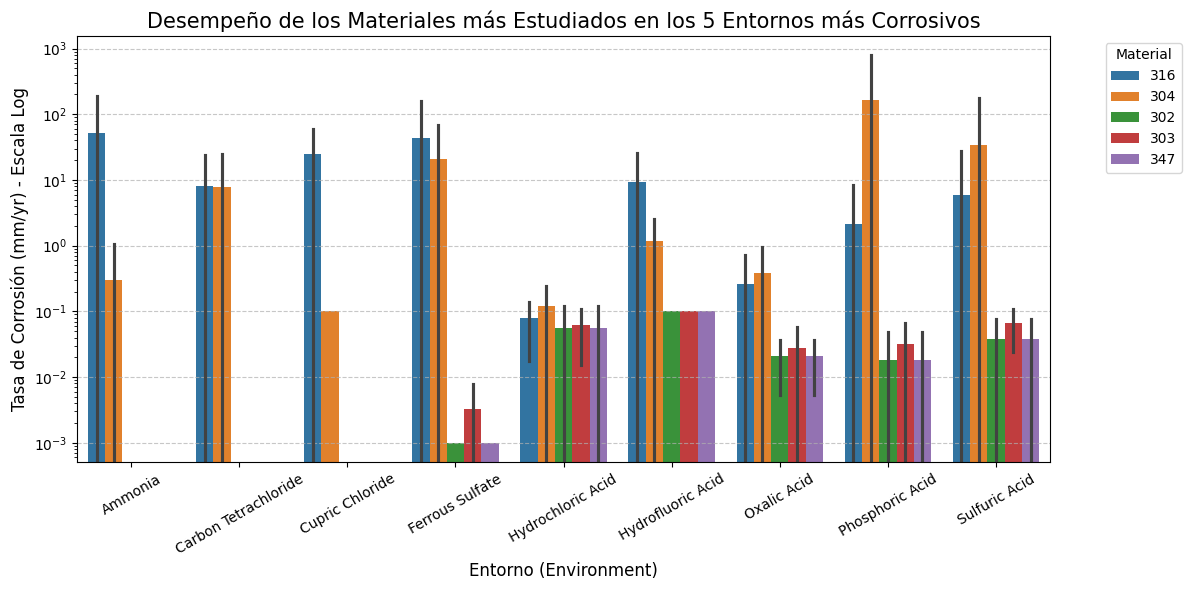

,mean,min,max,count
Environment,,,,
Ammonia,25.866643,0.003,360.00,14
Carbon Tetrachloride,7.911000,0.003,39.00,9
Cupric Chloride,16.733333,0.100,50.00,3
Ferrous Sulfate,20.525455,0.001,300.00,22
Hydrochloric Acid,0.075714,0.010,0.25,14
Hydrofluoric Acid,4.490300,0.002,51.00,40
Oxalic Acid,0.163744,0.001,1.23,39
Phosphoric Acid,50.864599,0.000,3950.00,258
Sulfuric Acid,11.765360,0.001,1400.00,517


In [ ]:
# 1. Obtener los 5 entornos más corrosivos (calculados previamente en env_corrosion)
top_5_corrosive_envs = df_aceros_final.groupby('Environment')['Rate (mm/yr) or Rating'].mean().sort_values(ascending=False).head(10).index

# 2. Filtrar para los materiales más estudiados
most_studied_materials = ['304', '316', '302', '303', '347']
df_aceros_mas_estudiados = df_aceros_final[(df_aceros_final['Material'].isin(most_studied_materials)) & (df_aceros_final['Environment'].isin(top_5_corrosive_envs))]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_aceros_mas_estudiados, x='Environment', y='Rate (mm/yr) or Rating', hue='Material', errorbar='sd')

plt.yscale('log')

plt.title('Desempeño de los Materiales más Estudiados en los 5 Entornos más Corrosivos', fontsize=15)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Log', fontsize=12)
plt.xlabel('Entorno (Environment)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Mostrar tabla de resumen
display(df_aceros_mas_estudiados.groupby('Environment')['Rate (mm/yr) or Rating'].agg(['mean', 'min', 'max', 'count']))

## Entornos menos corrosivos con los 5 materiales mas estudiados

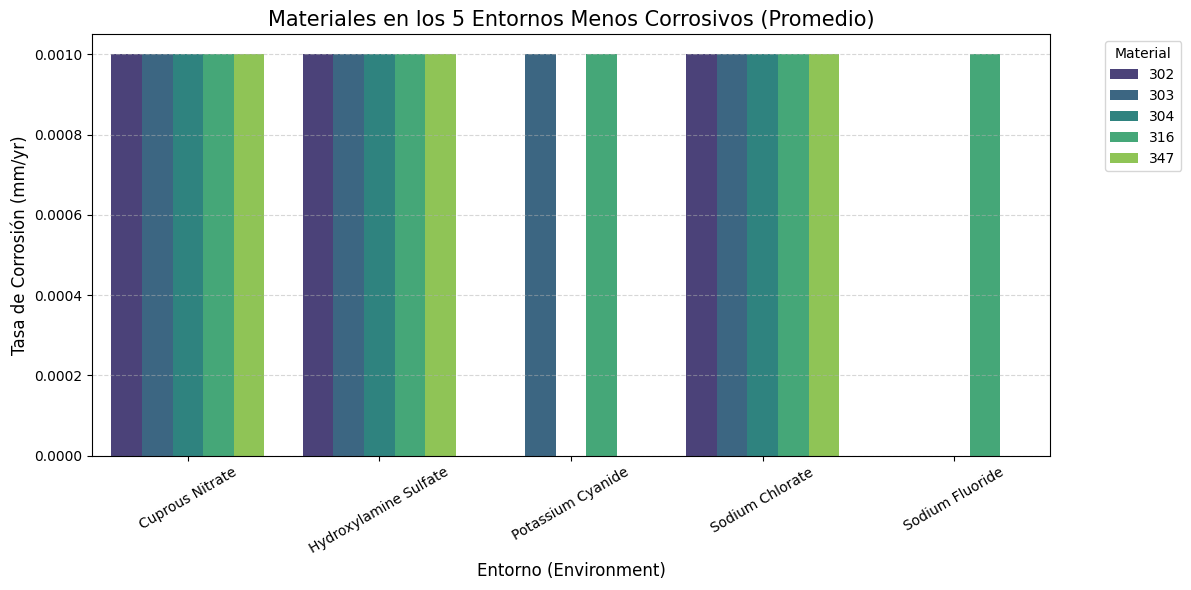

In [ ]:
# 1. Identificar los 5 entornos con menor tasa de corrosión promedio
least_corrosive_envs = df_aceros_final.groupby('Environment')['Rate (mm/yr) or Rating'].mean().sort_values(ascending=True).head(5).index

# 2. Filtrar el dataframe por esos entornos
df_least_env_subset = df_aceros_final[(df_aceros_final['Environment'].isin(least_corrosive_envs)) & (df_aceros_final['Material'].isin(most_studied_materials))]

# 3. Identificar los materiales con registros en esos entornos
plt.figure(figsize=(12, 6))
sns.barplot(data=df_least_env_subset, x='Environment', y='Rate (mm/yr) or Rating', hue='Material', errorbar=None, palette='viridis')


plt.title('Materiales en los 5 Entornos Menos Corrosivos (Promedio)', fontsize=15)
plt.ylabel('Tasa de Corrosión (mm/yr)', fontsize=12)
plt.xlabel('Entorno (Environment)', fontsize=12)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Desempeño del Material 304 en los entornos mas corrosivos

/tmp/ipykernel_2637/91622991.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Blue'` for the same effect.

  sns.barplot(data=df_304_performance, x='Environment', y='Rate (mm/yr) or Rating', hue='Environment', color='Blue', errorbar='sd', legend=False)


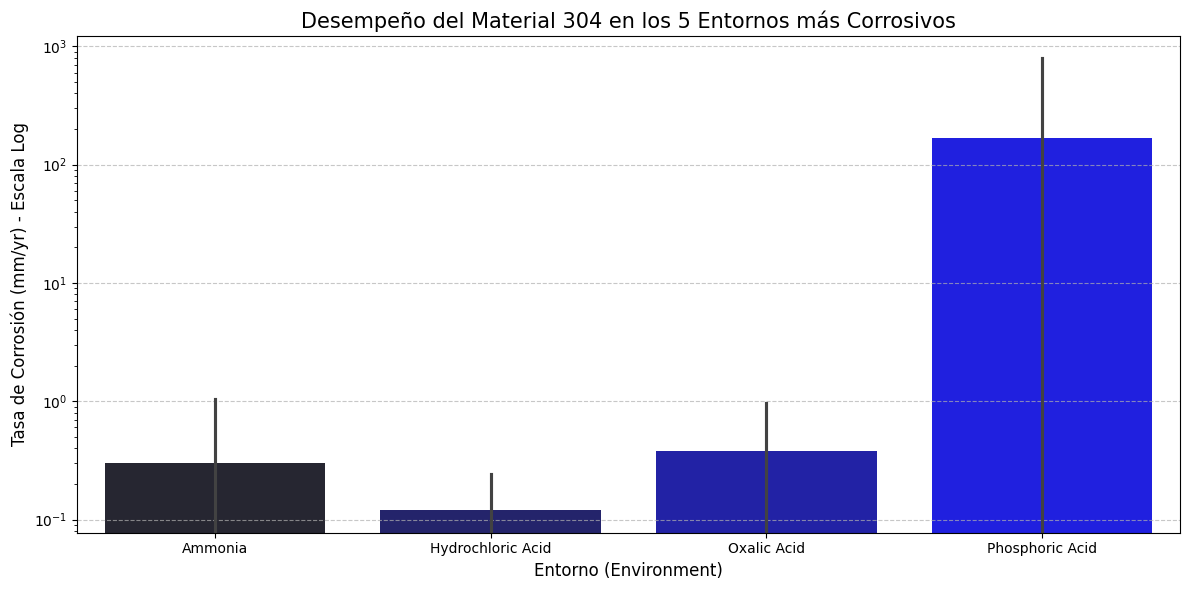

,mean,min,max,count
Environment,,,,
Ammonia,0.300429,0.003,2.00,7
Hydrochloric Acid,0.120000,0.010,0.25,3
Oxalic Acid,0.378600,0.001,1.23,10
Phosphoric Acid,166.672227,0.001,3950.00,77


In [ ]:
# 1. Obtener los 5 entornos más corrosivos (calculados previamente en env_corrosion)
top_5_corrosive_envs = df_aceros_final.groupby('Environment')['Rate (mm/yr) or Rating'].mean().sort_values(ascending=False).head(5).index

# 2. Filtrar para el material 304 en esos entornos
df_304_performance = df_aceros_final[(df_aceros_final['Material'] == '304') & (df_aceros_final['Environment'].isin(top_5_corrosive_envs))]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_304_performance, x='Environment', y='Rate (mm/yr) or Rating', hue='Environment', color='Blue', errorbar='sd', legend=False)

plt.yscale('log')

plt.title('Desempeño del Material 304 en los 5 Entornos más Corrosivos', fontsize=15)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Log', fontsize=12)
plt.xlabel('Entorno (Environment)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar tabla de resumen
display(df_304_performance.groupby('Environment')['Rate (mm/yr) or Rating'].agg(['mean', 'min', 'max', 'count']))

## Comparativa de Desempeño: Material 304 vs 316

Enlace para ver diferencias y usos de los dos tipos de aceros

https://www.thyssenkrupp-materials.es/es/home/blog/acero-inoxidable/que-es-acero-inoxidable-usos/mejor-acero-inoxidable-acero-304-acero-316

### Los 10 entornos con mayor presencia de estos dos materiales

Resumen Estadístico Comparativo:


,mean,median,std,max,count
Material,,,,,
304,22.955271,0.02145,208.169541,3950.0,794
316,2.801636,0.01000,19.349845,360.0,871


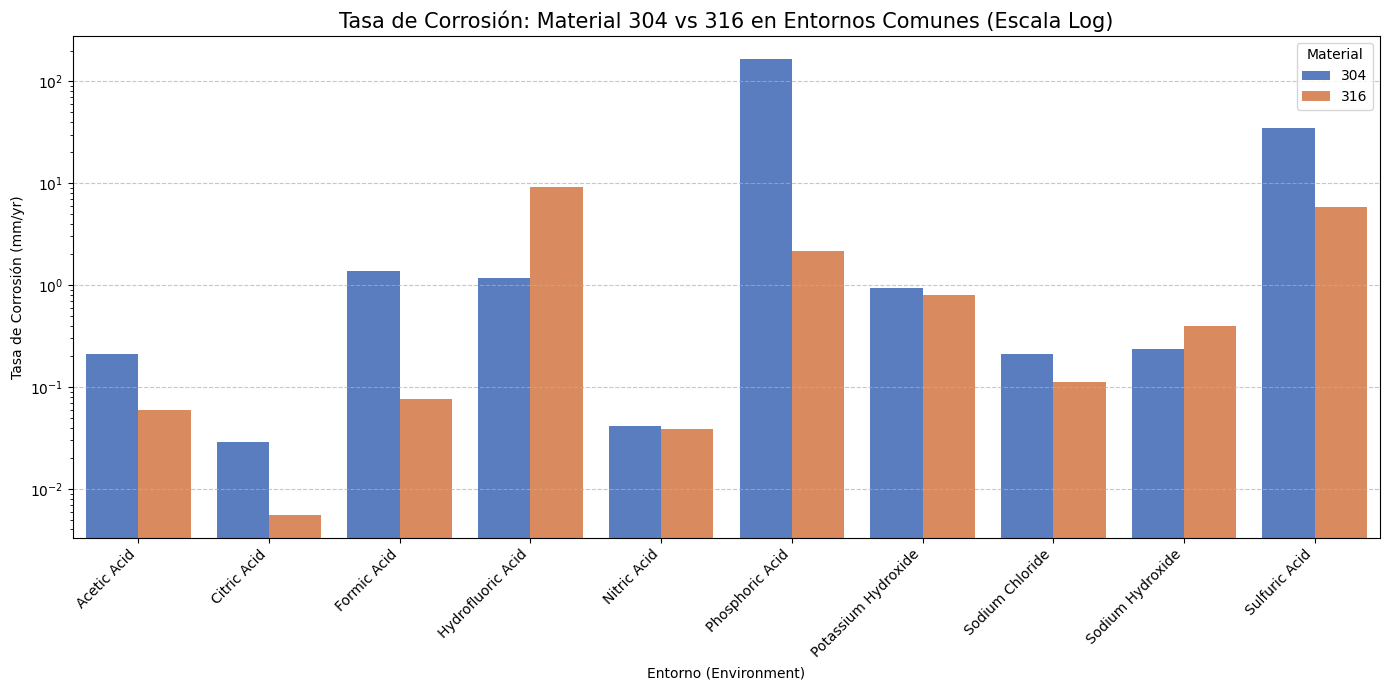

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el dataframe para incluir solo materiales 304 y 316
df_comp = df_aceros_final[df_aceros_final['Material'].isin(['304', '316'])].copy()

# Resumen estadístico comparativo
resumen_comp = df_comp.groupby('Material')['Rate (mm/yr) or Rating'].agg(['mean', 'median', 'std', 'max', 'count'])
print("Resumen Estadístico Comparativo:")
display(resumen_comp)

# Seleccionar los 10 entornos más comunes donde ambos materiales tienen presencia
envs_304 = set(df_comp[df_comp['Material'] == '304']['Environment'].unique())
envs_316 = set(df_comp[df_comp['Material'] == '316']['Environment'].unique())
common_envs = list(envs_304.intersection(envs_316))

top_common_envs = df_comp[df_comp['Environment'].isin(common_envs)]['Environment'].value_counts().nlargest(10).index
df_plot_comp = df_comp[df_comp['Environment'].isin(top_common_envs)]

# Visualización
plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot_comp, x='Environment', y='Rate (mm/yr) or Rating', hue='Material', palette='muted', errorbar=None)

plt.yscale('log')
plt.title('Tasa de Corrosión: Material 304 vs 316 en Entornos Comunes (Escala Log)', fontsize=15)
plt.ylabel('Tasa de Corrosión (mm/yr)', fontsize=10)
plt.xlabel('Entorno (Environment)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Análisis Profundo: Familia Austenitic Steel

In [ ]:
# 1. Filtrar solo aceros austeníticos
df_austeniticos = df_aceros_final[df_aceros_final['Material Family'] == 'Austenitic steel'].copy()

# 2. Contar la frecuencia de cada material específico
material_counts = df_austeniticos['Material'].value_counts()
print("Top 15 Materiales Austeníticos más frecuentes:")
display(material_counts.head(15))

# 3. Resumen estadístico de los materiales más comunes
top_materials_list = material_counts.head(10).index
resumen_austeniticos = df_austeniticos[df_austeniticos['Material'].isin(top_materials_list)].groupby('Material')['Rate (mm/yr) or Rating'].agg(['mean', 'median', 'std', 'count']).sort_values(by='median')

print("\nResumen Estadístico de los 10 materiales austeníticos principales (Ordenado por Mediana de Corrosión):")
display(resumen_austeniticos)

Top 15 Materiales Austeníticos más frecuentes:


,count
Material,
316,871
304,794
303,403
316L,232
347,229
302,219
317L,217
321,215
301,214



Resumen Estadístico de los 10 materiales austeníticos principales (Ordenado por Mediana de Corrosión):


,mean,median,std,count
Material,,,,
316L,5.439219,0.00100,35.655160,232
317L,0.761323,0.00100,4.441939,217
301,0.021444,0.01000,0.033193,214
302,0.234162,0.01000,3.087230,219
316,2.801636,0.01000,19.349845,871
303,0.033166,0.01000,0.040387,403
304L,0.030358,0.01000,0.066811,204
321,0.021809,0.01000,0.033546,215
347,0.047384,0.01000,0.159776,229


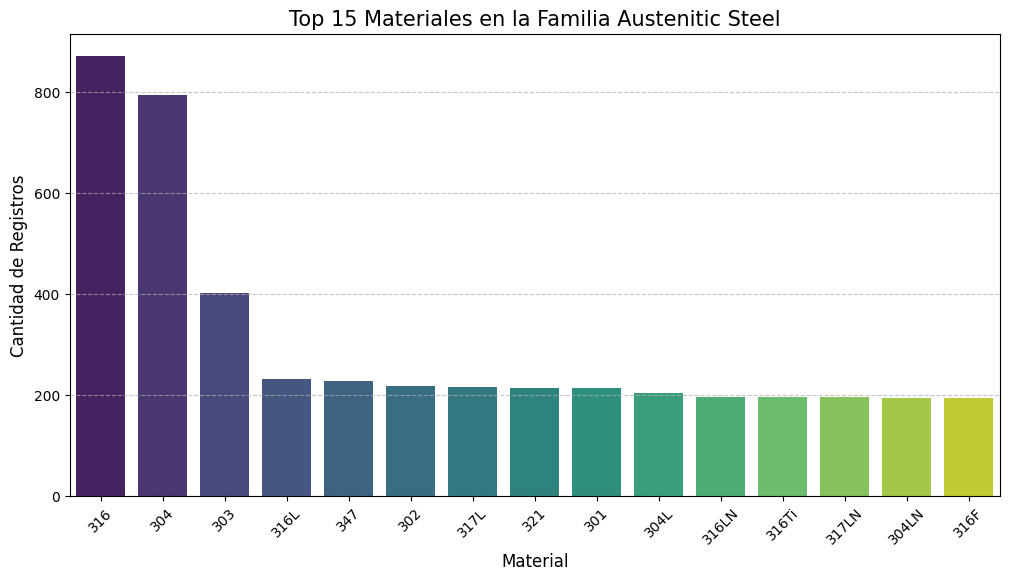

In [ ]:
#Visualización de la distribución de materiales principales
plt.figure(figsize=(12, 6))
sns.barplot(x=material_counts.head(15).index, y=material_counts.head(15).values, hue=material_counts.head(15).index, palette='viridis', legend=False)
plt.title('Top 15 Materiales en la Familia Austenitic Steel', fontsize=15)
plt.xlabel('Material', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Análisis de Corrosión vs Temperatura


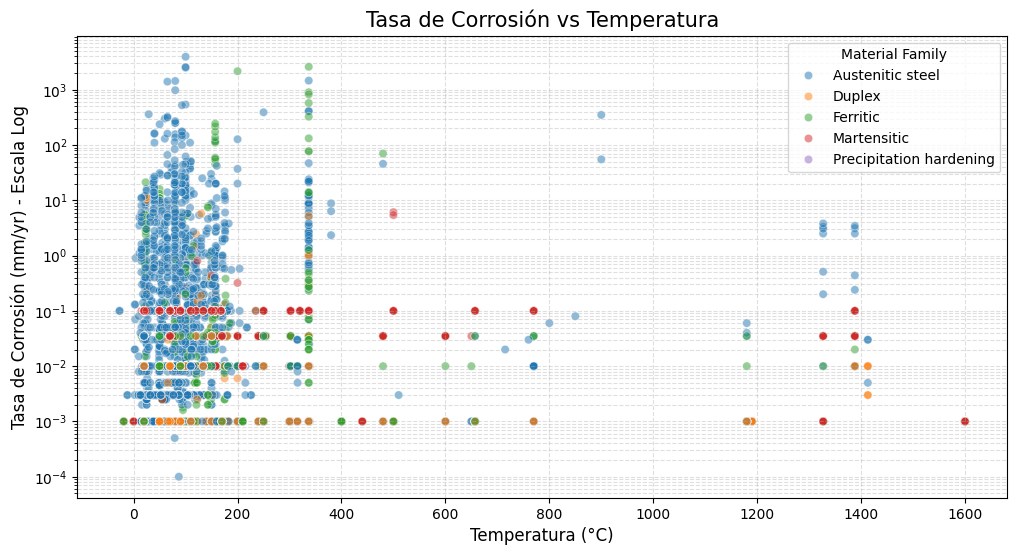

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_aceros_final, x='Temperature (deg C)', y='Rate (mm/yr) or Rating', alpha=0.5, hue='Material Family')

plt.yscale('log')

plt.title('Tasa de Corrosión vs Temperatura', fontsize=15)
plt.xlabel('Temperatura (°C)', fontsize=12)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Log', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.show()

## Promedio de corrosion de cada familia de acero dentro de un rango especifico de temperatura

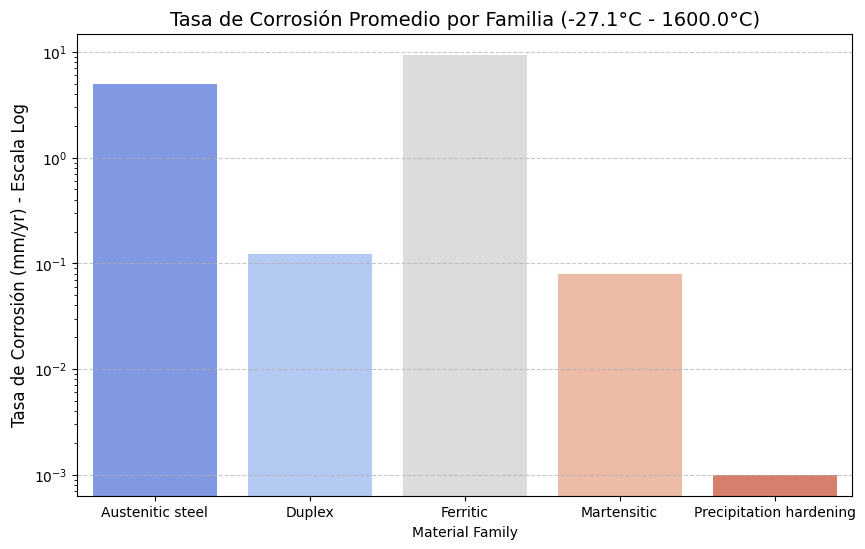

In [ ]:
# Definir el rango de interés
temp_min = df_aceros_final['Temperature (deg C)'].min() #modificar con alguna temperatura minima de interes
temp_max = df_aceros_final['Temperature (deg C)'].max() #modificar con alguna temperatura max de interes

# Visualizar la tasa de corrosión promedio por Familia en este rango
plt.figure(figsize=(10, 6))
# Fixed FutureWarning by assigning hue and setting legend=False
sns.barplot(data=df_aceros_final, x='Material Family', y='Rate (mm/yr) or Rating', hue='Material Family', palette='coolwarm', errorbar=None, legend=False)

plt.yscale('log')

plt.title(f'Tasa de Corrosión Promedio por Familia ({temp_min}°C - {temp_max}°C)', fontsize=14)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Log', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparación de Tasas de Corrosión por Entorno (Boxplot)
Visualizamos la distribución y variabilidad de la tasa de corrosión en los 10 entornos con mayor cantidad de registros registrados.

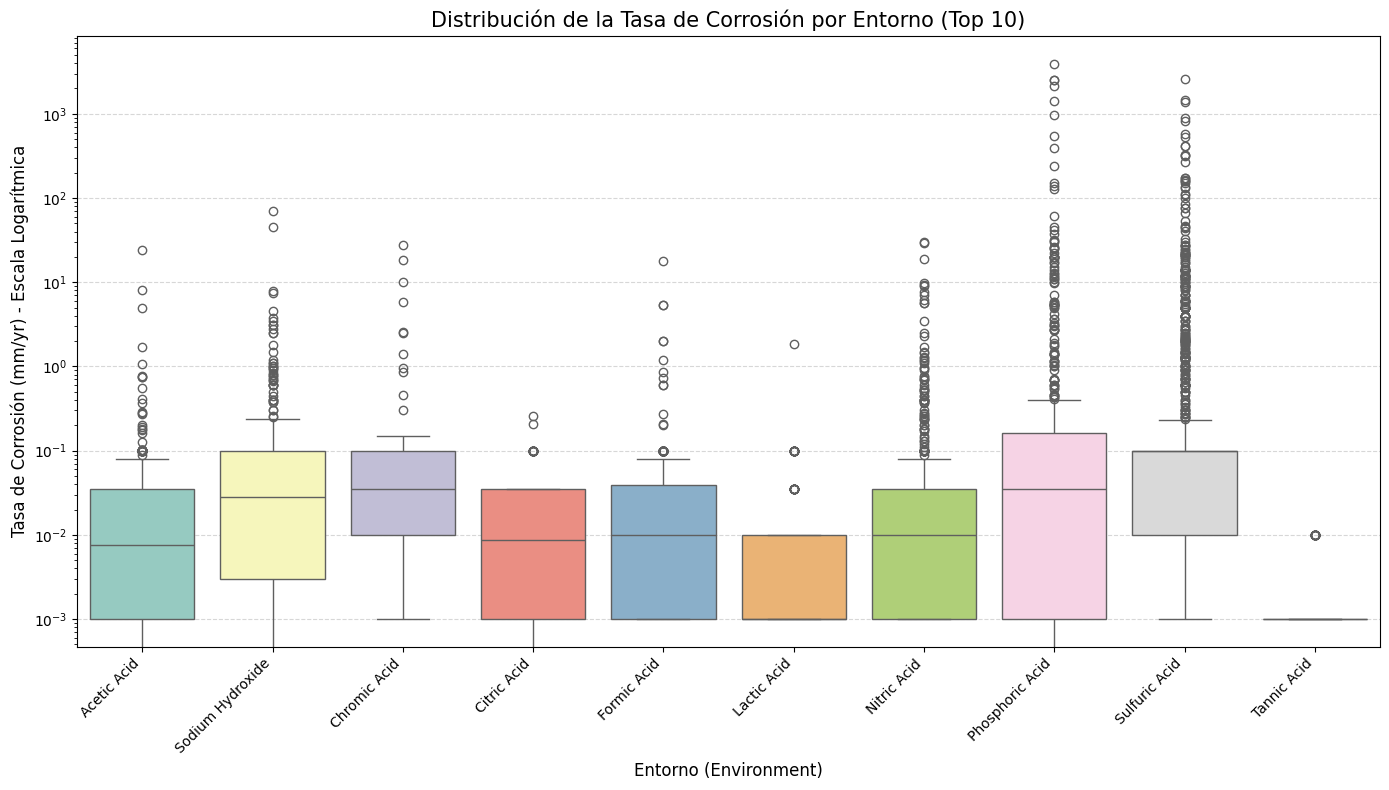

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos los 10 entornos más frecuentes para que el gráfico sea legible
top_10_envs = df_aceros_final['Environment'].value_counts().nlargest(10).index
df_box_plot = df_aceros_final[df_aceros_final['Environment'].isin(top_10_envs)]

plt.figure(figsize=(14, 8))
# Fixed FutureWarning by assigning x to hue and setting legend=False
sns.boxplot(data=df_box_plot, x='Environment', y='Rate (mm/yr) or Rating', hue='Environment', palette='Set3', legend=False)

# Usamos escala logarítmica para el eje Y debido a los valores extremos (outliers)
plt.yscale('log')

plt.title('Distribución de la Tasa de Corrosión por Entorno (Top 10)', fontsize=15)
plt.xlabel('Entorno (Environment)', fontsize=12)
plt.ylabel('Tasa de Corrosión (mm/yr) - Escala Logarítmica', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Mapa de Correlación
Analizamos la relación lineal entre las variables numéricas: Tasa de Corrosión, Duración y Temperatura (Numérica).

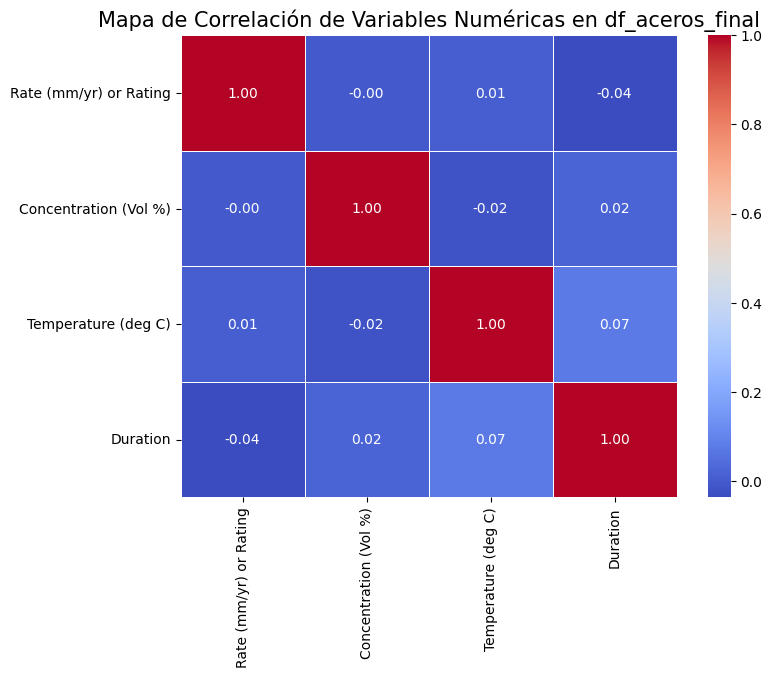

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

columns_to_corr = ['Rate (mm/yr) or Rating', 'Concentration (Vol %)', 'Temperature (deg C)', 'Duration']
corr_matrix = df_aceros_final[columns_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas en df_aceros_final', fontsize=15)
plt.show()